## Multiclass Classification with Logistic Regression

Multiclass classification on Landsat satellite imagery using scikit-learn's [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), evaluated with `classification_report` and `confusion_matrix` from `sklearn.metrics`.


## About the dataset

The database consists of the multi-spectral values of pixels in 3x3 neighbourhoods in a satellite image, and the classification associated with the central pixel in each neighbourhood. The aim is to predict this classification, given the multi-spectral values. In the sample database, the class of a pixel is coded as a number.

The Landsat satellite data is one of the many sources of information available for a scene. The interpretation of a scene by integrating spatial data of diverse types and resolutions including multispectral and radar data, maps indicating topography, land use etc. is expected to assume significant importance with the onset of an era characterised by integrative approaches to remote sensing (for example, NASA's Earth Observing System commencing this decade). Existing statistical methods are ill-equipped for handling such diverse data types. Note that this is not true for Landsat MSS data considered in isolation (as in this sample database). This data satisfies the important requirements of being numerical and at a single resolution, and standard maximum-likelihood classification performs very well. Consequently, for this data, it should be interesting to compare the performance of other methods against the statistical approach.

One frame of Landsat MSS imagery consists of four digital images of the same scene in different spectral bands. Two of these are in the visible region (corresponding approximately to green and red regions of the visible spectrum) and two are in the (near) infra-red. Each pixel is a 8-bit binary word, with 0 corresponding to black and 255 to white. The spatial resolution of a pixel is about 80m x 80m. Each image contains 2340 x 3380 such pixels.

The database is a (tiny) sub-area of a scene, consisting of 82 x 100 pixels. Each line of data corresponds to a 3x3 square neighbourhood of pixels completely contained within the 82x100 sub-area. Each line contains the pixel values in the four spectral bands (converted to ASCII) of each of the 9 pixels in the 3x3 neighbourhood and a number indicating the classification label of the central pixel. The number is a code for the following classes:

Number Class

1 red soil

2 cotton crop

3 grey soil

4 damp grey soil

5 soil with vegetation stubble

6 mixture class (all types present)

7 very damp grey soil

NB. There are no examples with class 6 in this dataset.

In each line of data the four spectral values for the top-left pixel are given first followed by the four spectral values for the top-middle pixel and then those for the top-right pixel, and so on with the pixels read out in sequence left-to-right and top-to-bottom. Thus, the four spectral values for the central pixel are given by attributes 17,18,19 and 20.


https://archive.ics.uci.edu/ml/datasets/Statlog+(Landsat+Satellite)


## 1. Importing the data and splitting it into train / validation / test


We read `186_satimage.csv`, take the first 36 columns as features and the last as the class label, and split 70 / 15 / 15 into training, validation and test sets. The split is stratified so every class keeps its proportion across all three sets, and `random_state=777` throughout keeps the run reproducible.


In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from IPython.display import display

# Importing data
df = pd.read_csv('186_satimage.csv', header=None)

# Separating features and labels
# 0-35 ,,, 36 for label
X_data = df.iloc[:, :36].to_numpy()
y_data = df.iloc[:, 36].to_numpy()

# The First split ---> 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, train_size=0.70, random_state=777, stratify=y_data)

# The Second split ---> 50% of temp to val / 50% to test -> 15% / 15%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=777, stratify=y_temp)

total_samples = X_data.shape[0]
print("#### Data Shapes ####")
print()
print(f"Total samples: {total_samples}")
print(f"X_train shape: {X_train.shape}   {(X_train.shape[0] / total_samples * 100):.0f}%")
print(f"X_val shape:   {X_val.shape}    {(X_val.shape[0] / total_samples * 100):.0f}%")
print(f"X_test shape:  {X_test.shape}    {(X_test.shape[0] / total_samples * 100):.0f}%")

#### Data Shapes ####

Total samples: 6430
X_train shape: (4501, 36)   70%
X_val shape:   (964, 36)    15%
X_test shape:  (965, 36)    15%


## 2. Checking the features and labels


A look at the basic statistics of the 36 features and the class distribution, plus a check that stratification held across the three splits.


In [39]:
print("### Feature Statistics (from original data) ###")
feature_stats = df.iloc[:, :36].describe().T
display(feature_stats)
print("\n")

# Label Statistics
print("### Label Distribution (from original data) ###")
label_stats = df.iloc[:, 36].value_counts().sort_index()
print(label_stats)
print("\n")

# Check Proportions
print("### Stratification Check for classes ###")

def get_proportions(y_arr):
    unique_classes, counts = np.unique(y_arr, return_counts=True)
    proportions = counts / len(y_arr)
    return dict(zip(unique_classes, proportions))


print(f"Original: {get_proportions(y_data)}")
print(f"Train:    {get_proportions(y_train)}")
print(f"Val:      {get_proportions(y_val)}")
print(f"Test:     {get_proportions(y_test)}")

### Feature Statistics (from original data) ###


,count,mean,std,min,25%,50%,75%,max
0,6430.0,-0.000846,0.999649,-2.234329,-0.690878,-0.102897,0.779075,2.543020
1,6430.0,-0.000748,0.999944,-2.473310,-0.550421,0.148811,0.848043,2.333912
2,6430.0,-0.000603,0.999965,-2.780894,-0.858503,0.102692,0.823588,2.445605
3,6430.0,-0.000272,1.000196,-2.624275,-0.719279,-0.084280,0.497802,3.778629
4,6430.0,-0.000863,0.999696,-2.223275,-0.674739,-0.084821,0.800057,2.569812
5,6430.0,-0.000787,0.999958,-2.457498,-0.534967,0.076748,0.863238,2.348830
6,6430.0,-0.000611,0.999968,-2.947095,-0.846770,0.113379,0.833490,2.753787
7,6430.0,-0.000333,1.000220,-2.824420,-0.712591,-0.079042,0.501711,3.933434
8,6430.0,-0.000767,0.999807,-2.146330,-0.661615,-0.141965,0.748864,2.604758
9,6430.0,-0.000779,0.999904,-2.444776,-0.520206,0.092157,0.835741,2.060467




### Label Distribution (from original data) ###
36
1    1531
2     703
3    1356
4     625
5     707
7    1508
Name: count, dtype: int64


### Stratification Check for classes ###
Original: {np.int64(1): np.float64(0.23810264385692068), np.int64(2): np.float64(0.1093312597200622), np.int64(3): np.float64(0.2108864696734059), np.int64(4): np.float64(0.09720062208398134), np.int64(5): np.float64(0.10995334370139968), np.int64(7): np.float64(0.23452566096423016)}
Train:    {np.int64(1): np.float64(0.238169295712064), np.int64(2): np.float64(0.10930904243501444), np.int64(3): np.float64(0.21084203510331037), np.int64(4): np.float64(0.0970895356587425), np.int64(5): np.float64(0.10997556098644745), np.int64(7): np.float64(0.23461453010442124)}
Val:      {np.int64(1): np.float64(0.237551867219917), np.int64(2): np.float64(0.10995850622406639), np.int64(3): np.float64(0.21058091286307054), np.int64(4): np.float64(0.0975103734439834), np.int64(5): np.float64(0.10995850622406639), np.int64(7)

## 3. Training a logistic regression classifier and tuning it on the validation set


We tune on the validation set and report the best configuration found. The test set stays sealed until the model is chosen.


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Standard-Scale for the features
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Fine-tuning the hyperparameter 'C'
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Tracking the best score and model
best_val_acc = 0.0
best_C = None
final_log_reg = None 

print("#### Tuning Hyperparameter C ####")

for C in C_values:
    # Create and train the model
    log_reg = LogisticRegression(C=C, multi_class='auto', solver='lbfgs', max_iter=1000, random_state=777)
    log_reg.fit(X_train_scaled, y_train)
    
    # Evaluating on -> validation set
    y_pred_val = log_reg.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    print(f"C = {C}:\t Validation Accuracy = {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        final_log_reg = log_reg 

print("\n#### Best Model Found ####")
print(f"Best C value: {best_C}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

#### Tuning Hyperparameter C ####
C = 0.001:	 Validation Accuracy = 0.8039
C = 0.01:	 Validation Accuracy = 0.8216
C = 0.1:	 Validation Accuracy = 0.8402
C = 1:	 Validation Accuracy = 0.8548
C = 10:	 Validation Accuracy = 0.8589
C = 100:	 Validation Accuracy = 0.8568


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

C = 1000:	 Validation Accuracy = 0.8579

#### Best Model Found ####
Best C value: 10
Best Validation Accuracy: 0.8589


## 4. Final evaluation on the test set


Final scoring on the held-out test set, with a full classification report and a confusion matrix, followed by observations.


Evaluating final model on the test set...

Final Test Accuracy: 0.8611
---

--- Classification Report on Test Set ---
                          precision    recall  f1-score   support

      Class 1 (red soil)       0.96      0.99      0.97       230
   Class 2 (cotton crop)       0.95      0.94      0.95       105
     Class 3 (grey soil)       0.88      0.92      0.90       204
Class 4 (damp grey soil)       0.53      0.34      0.42        94
   Class 5 (veg stubble)       0.83      0.77      0.80       106
Class 7 (very damp soil)       0.81      0.90      0.85       226

                accuracy                           0.86       965
               macro avg       0.83      0.81      0.81       965
            weighted avg       0.85      0.86      0.85       965


#### Confusion Matrix on Test Set ####


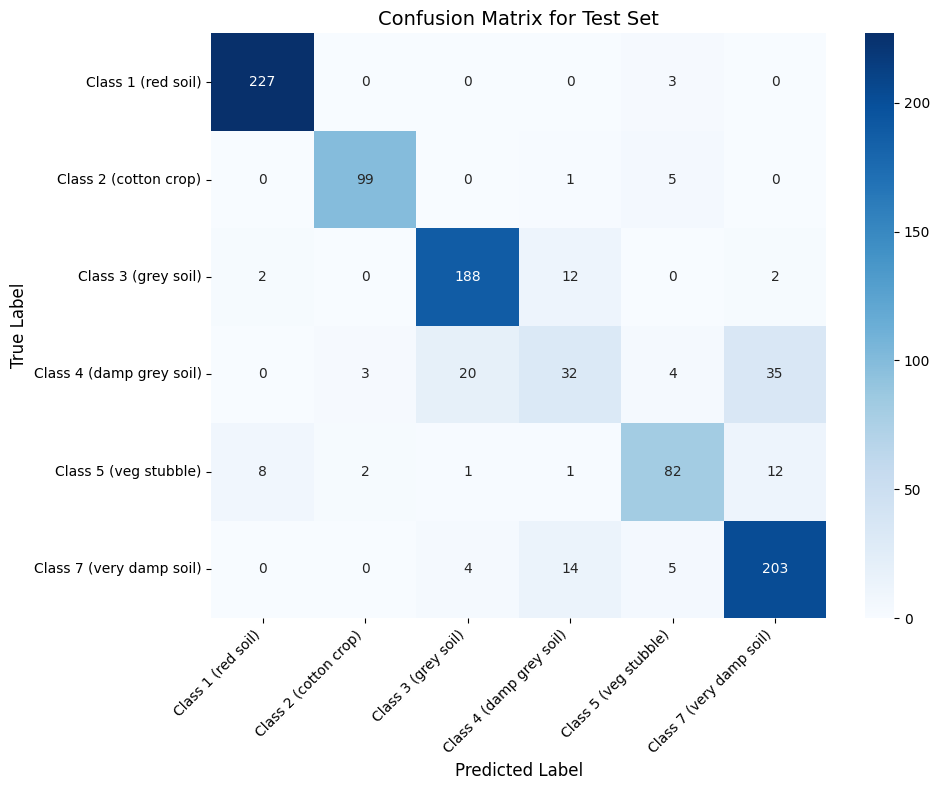

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print("Evaluating final model on the test set...")
y_pred_test = final_log_reg.predict(X_test_scaled)

# Calculate final test accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print("---")

# Reporting Classification Report
print("\n--- Classification Report on Test Set ---")

# Define meaningful class names
class_labels_numeric = sorted(np.unique(y_data)) 
class_names_desc = [
    "Class 1 (red soil)", 
    "Class 2 (cotton crop)", 
    "Class 3 (grey soil)", 
    "Class 4 (damp grey soil)", 
    "Class 5 (veg stubble)", 
    "Class 7 (very damp soil)"
]

print(classification_report(y_test, y_pred_test, labels=class_labels_numeric, target_names=class_names_desc))

# Reporting Confusion Matrix
print("\n#### Confusion Matrix on Test Set ####")

cm = confusion_matrix(y_test, y_pred_test, labels=class_labels_numeric)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_desc, 
            yticklabels=class_names_desc)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [42]:
print("----- Observations on Final Test Results -----")
print("\n")

print("1. Overall Model Performance:")
print(" - Final test accuracy: 0.8611 (86.11%).")
print(" - Macro avg (precision/recall/f1): 0.83 / 0.81 / 0.81 — model performs reasonably across classes but class-level variation exists.")
print(" - Weighted avg (precision/recall/f1): 0.85 / 0.86 / 0.85 — overall performance is driven by larger classes (e.g., Class 1 and Class 7).")
print("\n")

print("2. Best-performing class:")
print(" - Class 1 (red soil) is the strongest: precision 0.96, recall 0.99, F1-score 0.97 (support = 230).")
print(" - Very few misclassifications for this class (227 correct out of 230 in the confusion matrix).")
print("\n")

print("3. Classes with solid performance:")
print(" - Class 2 (cotton crop): precision 0.95, recall 0.94, F1 0.95 (support = 105).")
print(" - Class 3 (grey soil): precision 0.88, recall 0.92, F1 0.90 (support = 204).")
print(" - Class 5 (veg stubble): precision 0.83, recall 0.77, F1 0.80 (support = 106).")
print("\n")

print("4. Biggest issues / confusion:")
print(" - Class 4 (damp grey soil) performs poorly: precision 0.53, recall 0.34, F1 0.42 (support = 94).")
print(" - Major confusion between Class 4 and Class 7:")
print(" - 35 true Class 4 samples were predicted as Class 7.")
print(" - 14 true Class 7 samples were predicted as Class 4.")
print(" - This likely reflects high visual similarity between 'damp grey soil' and 'very damp soil'.")
print("\n")

print("5. Notes on Class 7 (very damp soil):")
print(" - Class 7 has decent recall (0.90) and F1 (0.85) but its precision (0.81) is lowered by mistaken Class 4 → Class 7 predictions (35 cases).")
print("\n")

----- Observations on Final Test Results -----


1. Overall Model Performance:
 - Final test accuracy: 0.8611 (86.11%).
 - Macro avg (precision/recall/f1): 0.83 / 0.81 / 0.81 — model performs reasonably across classes but class-level variation exists.
 - Weighted avg (precision/recall/f1): 0.85 / 0.86 / 0.85 — overall performance is driven by larger classes (e.g., Class 1 and Class 7).


2. Best-performing class:
 - Class 1 (red soil) is the strongest: precision 0.96, recall 0.99, F1-score 0.97 (support = 230).
 - Very few misclassifications for this class (227 correct out of 230 in the confusion matrix).


3. Classes with solid performance:
 - Class 2 (cotton crop): precision 0.95, recall 0.94, F1 0.95 (support = 105).
 - Class 3 (grey soil): precision 0.88, recall 0.92, F1 0.90 (support = 204).
 - Class 5 (veg stubble): precision 0.83, recall 0.77, F1 0.80 (support = 106).


4. Biggest issues / confusion:
 - Class 4 (damp grey soil) performs poorly: precision 0.53, recall 0.34, F1 0.